# 6. Inference & Live Verification

Live Facial Verification using a webcam.

**Features:**
- Webcam Capture
- Real-time Face Verification
- Similarity Score Display
- Configurable Threshold

**Note:** This notebook can only be run locally (requires a webcam)

## 6.1 Import & Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import cv2
import tensorflow as tf
import keras
from src.models import L1Dist
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Project
sys.path.insert(0, str(Path.cwd().parent))
import config
from src import data, training, utils

# Default values so that later cells don't abort with a name error
siamese_model = None
anchor_paths = []

print("✓ Imports successful")

✓ Imports successful


## 6.2 Loading Model

In [2]:
# Find latest checkpoint
best_checkpoint = training.get_best_checkpoint(str(config.CHECKPOINT_DIR)) or str(config.CHECKPOINT_DIR / "siamese_final.keras")

print(f"Loading model from: {best_checkpoint}\n")

try:
    siamese_model = keras.models.load_model(
        best_checkpoint,
        custom_objects={'L1Dist': L1Dist}
    )
    print("✓ Model loaded successfully")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    siamese_model = None

Loading model from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/checkpoints/siamese_epoch_0016.keras



I0000 00:00:1784495647.001435 3762257 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784495647.001529 3762257 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✓ Model loaded successfully


## 6.3 Anchor Image Choice

In [3]:
if siamese_model is not None:
    # Load anchor images
    anchor_paths = data.load_image_paths(str(config.ANCHOR_PATH))

    print(f"\nAnchor images available: {len(anchor_paths)}")
    print(f"\nSelecting a random anchor image...")

    if anchor_paths:
        import random
        anchor_path = random.choice(anchor_paths)
        anchor_img = data.load_image(anchor_path).numpy().astype(np.uint8)
        anchor_img_processed = data.preprocess_image(data.load_image(anchor_path)).numpy()

        print(f"✓ Anchor: {Path(anchor_path).name}")
        print(f"  Shape: {anchor_img.shape}")
    else:
        print("✗ No anchor images found")


Anchor images available: 400

Selecting a random anchor image...
✓ Anchor: 2e581984-5d76-4605-89a4-e9e033c31901.jpg
  Shape: (750, 750, 3)


## 6.4 Test with Image Examples


Testing with image examples (webcam alternative)...



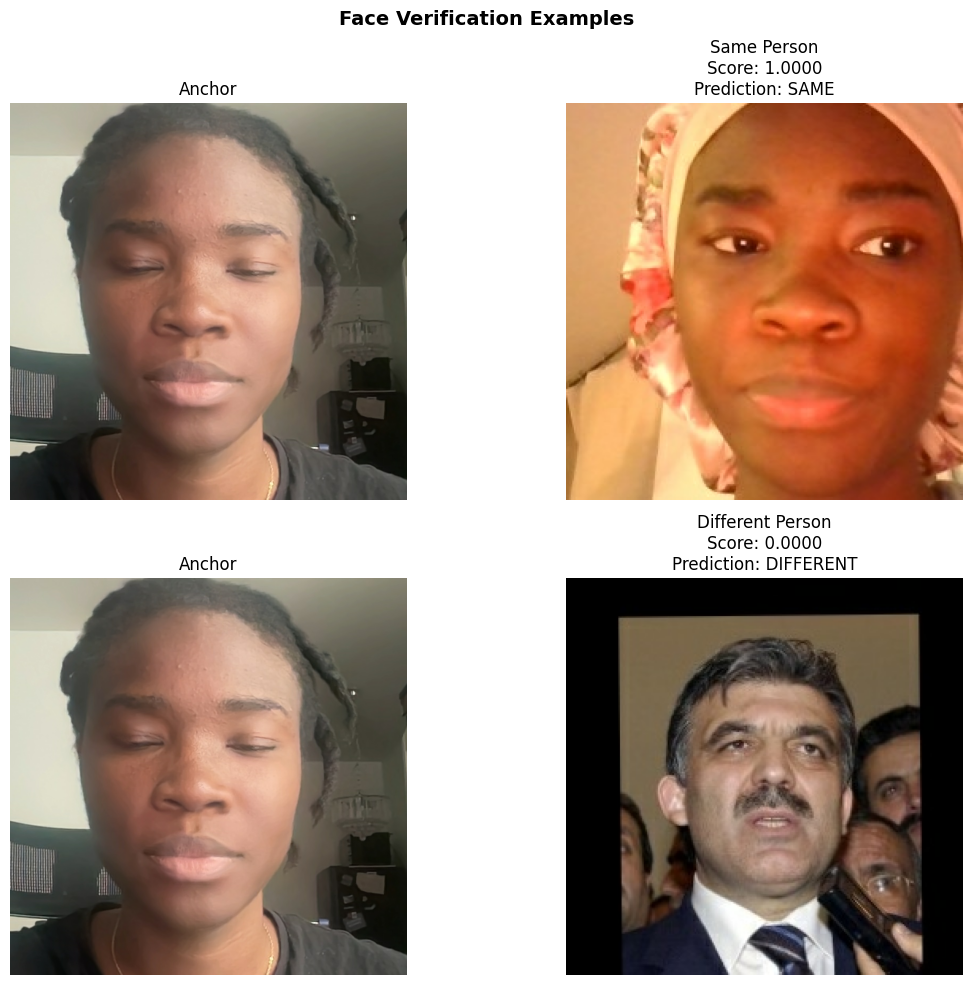


✓ Verification test completed successfully


In [6]:
# Alternative to Webcam: Test with saved images
if siamese_model is not None and anchor_paths:
    print("\nTesting with image examples (webcam alternative)...\n")

    # Load test images
    positive_paths = data.load_image_paths(str(config.POSITIVE_PATH))
    negative_paths = data.load_image_paths(str(config.NEGATIVE_PATH))

    # Select random pairs
    import random

    # Positive Pair (same person)
    anchor_idx = random.randint(0, min(200, len(anchor_paths)-1))
    positive_idx = random.randint(0, min(200, len(positive_paths)-1))

    anchor_img_pos = data.load_image(anchor_paths[anchor_idx]).numpy()
    positive_img = data.load_image(positive_paths[positive_idx]).numpy()

    anchor_img_pos_proc = data.preprocess_image(data.load_image(anchor_paths[anchor_idx])).numpy()
    positive_img_proc = data.preprocess_image(data.load_image(positive_paths[positive_idx])).numpy()

    # Negative Pair (different person)
    negative_idx = random.randint(0, min(200, len(negative_paths)-1))
    negative_img = data.load_image(negative_paths[negative_idx]).numpy()
    negative_img_proc = data.preprocess_image(data.load_image(negative_paths[negative_idx])).numpy()

    # Verify both pairs
    sim_positive, is_same_pos = utils.verify_faces(siamese_model, anchor_img_pos_proc, positive_img_proc)
    sim_negative, is_same_neg = utils.verify_faces(siamese_model, anchor_img_pos_proc, negative_img_proc)

    # Visualize results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Face Verification Examples', fontsize=14, fontweight='bold')

    # Positive Pair
    axes[0, 0].imshow(anchor_img_pos.astype(np.uint8))
    axes[0, 0].set_title('Anchor')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(positive_img.astype(np.uint8))
    axes[0, 1].set_title(f'Same Person\nScore: {sim_positive:.4f}\nPrediction: {"SAME" if is_same_pos else "DIFFERENT"}')
    axes[0, 1].axis('off')

    # Negative Pair
    axes[1, 0].imshow(anchor_img_pos.astype(np.uint8))
    axes[1, 0].set_title('Anchor')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(negative_img.astype(np.uint8))
    axes[1, 1].set_title(f'Different Person\nScore: {sim_negative:.4f}\nPrediction: {"SAME" if is_same_neg else "DIFFERENT"}')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n✓ Verification test completed successfully")

## 6.5 Summary

In [5]:
print("\n" + "="*80)
print("INFERENCE SUMMARY")
print("="*80)

print(f"\n✓ Facial Verification System:")
print(f"  - Model loaded and ready for use")
print(f"  - Verification Threshold: {config.VERIFICATION_THRESHOLD}")
print(f"  - Input Size: {config.IMG_SIZE}x{config.IMG_SIZE}")

print(f"\n✓ Live Verification (Webcam):")
print(f"  - Crop Region: {config.WEBCAM_FRAME_SIZE}x{config.WEBCAM_FRAME_SIZE}")
print(f"  - Offset: ({config.WEBCAM_OFFSET_X}, {config.WEBCAM_OFFSET_Y})")

print(f"\n✓ Ready for Deployment!")
print(f"\nNext Steps:")
print(f"  - Tune hyperparameters and retrain if necessary")
print(f"  - Deploy model to Unicluster for batch processing")
print(f"  - Develop web interface (optional)")

print("\n" + "="*80)
print("✓ Notebook 06 completed!")
print("="*80)


INFERENCE SUMMARY

✓ Facial Verification System:
  - Model loaded and ready for use
  - Verification Threshold: 0.7
  - Input Size: 100x100

✓ Live Verification (Webcam):
  - Crop Region: 250x250
  - Offset: (200, 120)

✓ Ready for Deployment!

Next Steps:
  - Tune hyperparameters and retrain if necessary
  - Deploy model to Unicluster for batch processing
  - Develop web interface (optional)

✓ Notebook 06 completed!
